# Dataset 05 - Percepciones sociales sobre IA
Analisis descriptivo con `Data_set_05.csv`.
Objetivo: resumir percepciones de confianza, beneficios/risgos y efectos laborales.
Nota: se normalizan proporciones para comparar categorias.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

try:
    df = pd.read_csv("./Dataset/Data_set_05.csv", encoding="utf-8-sig")
except UnicodeDecodeError:
    df = pd.read_csv("./Dataset/Data_set_05.csv", encoding="latin1")

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 205 filas x 20 columnas


,ID,What is your age range?,What is your gender?,What is your education level?,What is your employment status?,What is your occupation? (optional),How often do you use technological devices?,How much knowledge do you have about artificial intelligence (AI) technologies?,Do you generally trust artificial intelligence (AI)?,Do you think artificial intelligence (AI) will be generally beneficial or harmful to humanity?,Please rate how actively you use AI-powered products in your daily life on a scale from 1 to 5.,Would you like to use more AI products in the future?,I think artificial intelligence (AI) could threaten individual freedoms.,Could artificial intelligence (AI) completely eliminate some professions?,Do you think your own job could be affected by artificial intelligence (AI)?,Do you believe that artificial intelligence (AI) should be limited by ethical rules?,Could artificial intelligence (AI) one day become conscious like humans?,Which of the following do you think is NOT an artificial intelligence (AI) application?,Which of the following is a machine learning algorithm used in the field of artificial intelligence?,The artificial intelligence application called 'ChatGPT' is an example of which type of AI system?
0,1,18-24,Male,Bachelor's degree,Student,NaN,Between 5 to 10 hours per day,I have a good level of knowledge,I'm undecided,Both beneficial and harmful,4,I would like to,Agree,Removes,I definitely think,I'm undecided,Becomes,WhatsApp,Game algorithm,Web browser
1,2,18-24,Female,Bachelor's degree,Student,NaN,Between 2 to 5 hours per day,I have basic knowledge,I don't trust it,More harmful than beneficial,3,I'm undecided,Agree,I have no idea,I'm undecided,Agree,Becomes,WhatsApp,HTML,Web browser
2,3,18-24,Male,Bachelor's degree,Student,Student,Between 5 to 10 hours per day,I have a good level of knowledge,I'm undecided,Both beneficial and harmful,3,I would like to,Agree,Definitely Removes,I'm undecided,Agree,It certainly can't be,WhatsApp,Linear regression,Natural language processing
3,4,18-24,Male,Bachelor's degree,Student,engineer,Between 2 to 5 hours per day,I have basic knowledge,I'm undecided,Both beneficial and harmful,2,I would like to,I'm undecided,Removes,Think,Agree,I'm undecided,WhatsApp,HTML,Web browser
4,5,18-24,Male,Ön Bachelor's degree,Student,NaN,Between 2 to 5 hours per day,I've heard a little about it,I'm undecided,Both beneficial and harmful,1,I would like to,Agree,Removes,I'm undecided,Agree,I'm undecided,WhatsApp,I do not know,Web browser


In [9]:
rename_map = {
    "What is your age range?": "age_range",
    "What is your gender?": "gender",
    "What is your education level?": "education",
    "Do you generally trust artificial intelligence (AI)?": "trust_ai",
    "Do you think artificial intelligence (AI) will be generally beneficial or harmful to humanity?": "benefit_ai",
    "I think artificial intelligence (AI) could threaten individual freedoms.": "threat_freedoms",
    "Do you think your own job could be affected by artificial intelligence (AI)?": "job_affected",
    "Do you believe that artificial intelligence (AI) should be limited by ethical rules?": "ethical_rules",
}

df = df.rename(columns=rename_map)

key_cols = list(rename_map.values())
for col in key_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

df[key_cols].head()

,age_range,gender,education,trust_ai,benefit_ai,threat_freedoms,job_affected,ethical_rules
0,18-24,Male,Bachelor's degree,I'm undecided,Both beneficial and harmful,Agree,I definitely think,I'm undecided
1,18-24,Female,Bachelor's degree,I don't trust it,More harmful than beneficial,Agree,I'm undecided,Agree
2,18-24,Male,Bachelor's degree,I'm undecided,Both beneficial and harmful,Agree,I'm undecided,Agree
3,18-24,Male,Bachelor's degree,I'm undecided,Both beneficial and harmful,I'm undecided,Think,Agree
4,18-24,Male,Ön Bachelor's degree,I'm undecided,Both beneficial and harmful,Agree,I'm undecided,Agree


In [10]:
def translate_series(series, mapping):
    return series.replace(mapping)

trust_map = {
    "I trust it": "Confio en la IA",
    "I don't trust it": "No confio en la IA",
    "I'm undecided": "Indeciso",
}

benefit_map = {
    "More beneficial than harmful": "Mas beneficiosa que danina",
    "More harmful than beneficial": "Mas danina que beneficiosa",
    "Both beneficial and harmful": "Beneficiosa y danina",
    "I have no idea": "No se",
}

threat_map = {
    "Strongly agree": "Muy de acuerdo",
    "Agree": "De acuerdo",
    "I'm undecided": "Indeciso",
    "Disagree": "En desacuerdo",
    "Strongly disagree": "Muy en desacuerdo",
}

ethical_map = threat_map.copy()

job_map = {
    "I definitely think": "Definitivamente si",
    "I don't think so": "Creo que no",
    "I'm undecided": "Indeciso",
    "I have no idea": "No se",
    "I definitely think": "Definitivamente si",
}

df["trust_ai_es"] = translate_series(df["trust_ai"], trust_map)
df["benefit_ai_es"] = translate_series(df["benefit_ai"], benefit_map)
df["threat_freedoms_es"] = translate_series(df["threat_freedoms"], threat_map)
df["ethical_rules_es"] = translate_series(df["ethical_rules"], ethical_map)
df["job_affected_es"] = translate_series(df["job_affected"], job_map)

trust_order = ["Confio en la IA", "Indeciso", "No confio en la IA"]
benefit_order = ["Mas beneficiosa que danina", "Beneficiosa y danina", "Mas danina que beneficiosa", "No se"]
threat_order = ["Muy de acuerdo", "De acuerdo", "Indeciso", "En desacuerdo", "Muy en desacuerdo"]
ethical_order = threat_order
job_order = ["Definitivamente si", "Creo que no", "Indeciso", "No se"]

In [11]:
def plot_percent_bar(series, title, ax=None, color="#5b9bd5", order=None):
    counts = series.value_counts(dropna=True)
    if order is not None:
        counts = counts.reindex(order).dropna()
    pct = (counts / counts.sum() * 100).round(1)
    if ax is None:
        ax = plt.gca()
    sns.barplot(x=pct.values, y=pct.index, color=color, ax=ax)
    for i, v in enumerate(pct.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
    ax.set_title(title)
    ax.set_xlabel("Porcentaje")
    ax.set_ylabel("")
    ax.set_xlim(0, max(10, pct.max() * 1.15))
    return ax

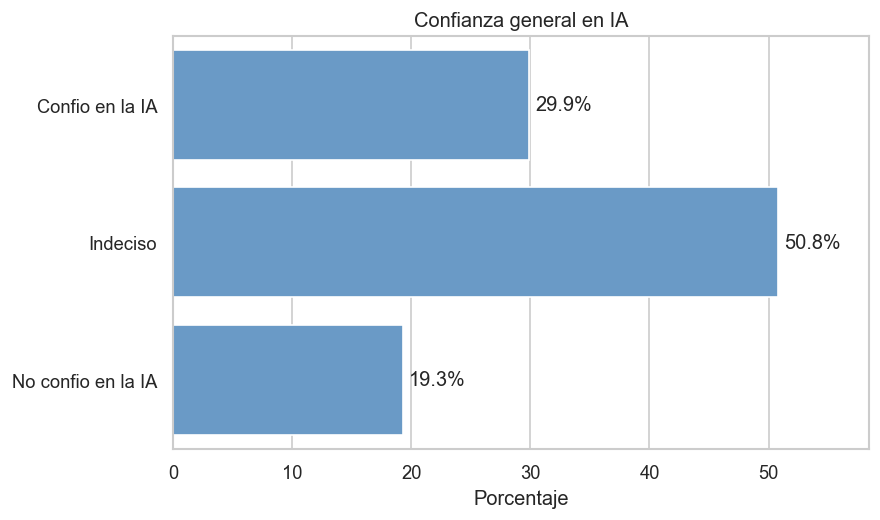

In [12]:
plt.figure(figsize=(7.5, 4.5))
plot_percent_bar(df["trust_ai_es"], "Confianza general en IA", order=trust_order)
plt.tight_layout()
plt.show()

Interpretacion: la distribucion de confianza permite ver si predomina confianza, desconfianza o postura intermedia frente a la IA.
Para el informe: sirve para contextualizar percepciones generales de la poblacion y enlazar con privacidad/seguridad.

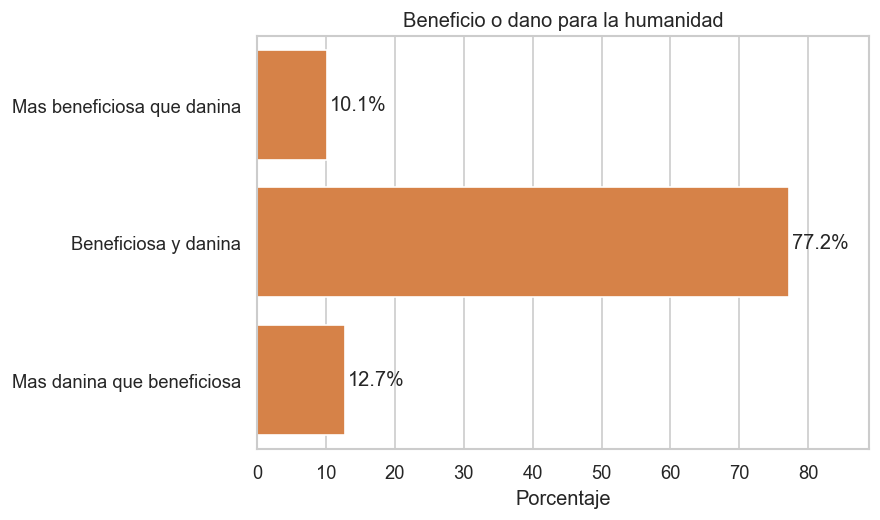

In [14]:
plt.figure(figsize=(7.5, 4.5))
plot_percent_bar(
    df["benefit_ai_es"],
    "Beneficio o dano para la humanidad",
    color="#ed7d31",
    order=benefit_order,
 )
plt.tight_layout()
plt.show()

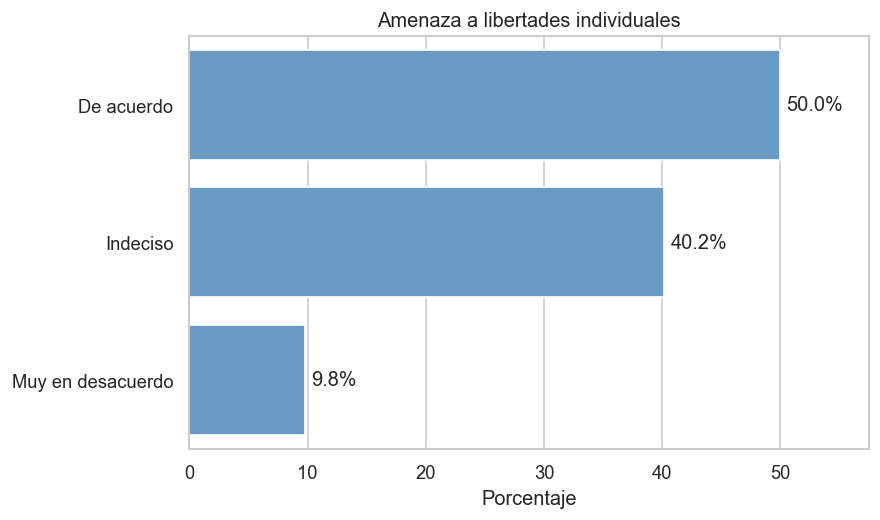

In [15]:
plt.figure(figsize=(7.5, 4.5))
plot_percent_bar(
    df["threat_freedoms_es"],
    "Amenaza a libertades individuales",
    color="#5b9bd5",
    order=threat_order,
 )
plt.tight_layout()
plt.show()

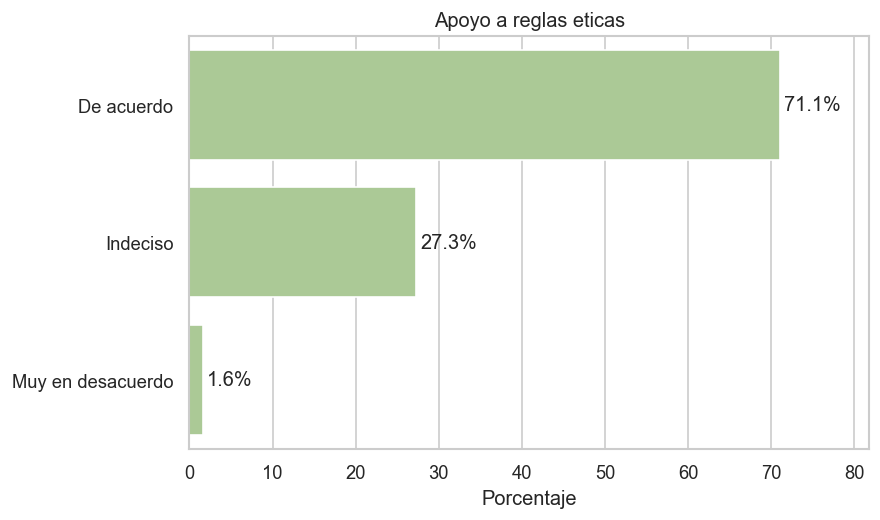

In [16]:
plt.figure(figsize=(7.5, 4.5))
plot_percent_bar(
    df["ethical_rules_es"],
    "Apoyo a reglas eticas",
    color="#a9d18e",
    order=ethical_order,
 )
plt.tight_layout()
plt.show()

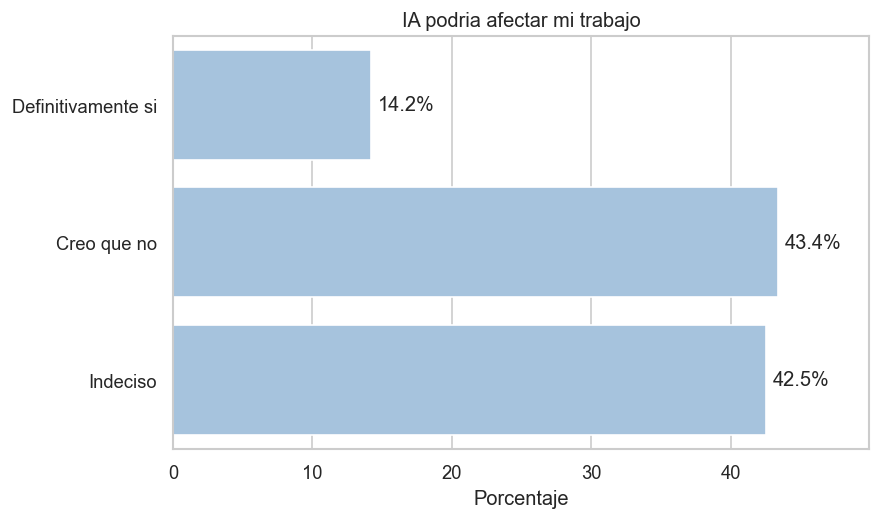

In [17]:
plt.figure(figsize=(7.5, 4.5))
plot_percent_bar(
    df["job_affected_es"],
    "IA podria afectar mi trabajo",
    color="#9dc3e6",
    order=job_order,
 )
plt.tight_layout()
plt.show()

Interpretacion: se observa el balance entre percepciones de beneficio, amenaza a libertades y apoyo a regulacion etica, junto con la preocupacion por el empleo.
Para el informe: conecta directamente con las dimensiones de privacidad/seguridad y productividad/empleo.

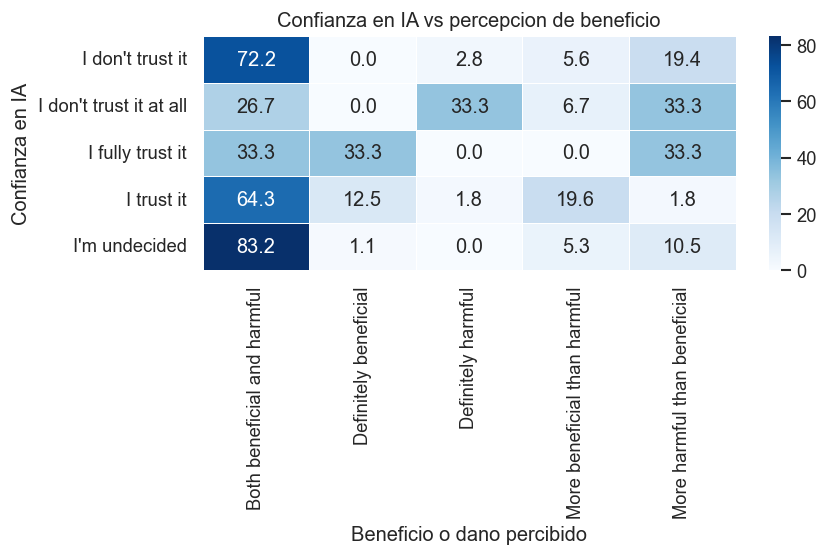

In [ ]:
ct = pd.crosstab(df["trust_ai_es"], df["benefit_ai_es"], normalize="index") * 100
plt.figure(figsize=(7.5, 4.8))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", linewidths=0.4)
plt.title("Confianza en IA vs percepcion de beneficio")
plt.xlabel("Beneficio o dano percibido")
plt.ylabel("Confianza en IA")
plt.tight_layout()
plt.show()

Interpretacion: la matriz muestra como cambia la percepcion de beneficio segun el nivel de confianza, evidenciando perfiles de riesgo o aceptacion.
Para el informe: permite argumentar que la confianza condiciona la evaluacion social de la IA.